In [3]:
!pip install -U datasets
!pip install wikipedia
!pip install sympy

In [2]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback
)
from datasets import load_dataset

# ds = load_dataset("AI-MO/NuminaMath-CoT")
ds = load_dataset("5CD-AI/Vietnamese-395k-meta-math-MetaMathQA-gg-translated")['train'].to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/129 [00:00<?, ?B/s]

MetaMathQA-395K_json_vi.json:   0%|          | 0.00/890M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/395000 [00:00<?, ? examples/s]

In [4]:
# train_test_split_ds = ds['train'].train_test_split(test_size=0.3, seed=42, shuffle=True)
# train_ds = train_test_split_ds['train']
# eval_ds = train_test_split_ds['test']

In [5]:
# train_ds = train_ds.to_pandas()
# eval_ds = eval_ds.to_pandas()

In [6]:
ds.head()

,response_en,original_question_en,type,query_en,original_question_vi,query_vi,response_vi
0,"The distance between two points $(x_1,y_1)$ an...",Gracie and Joe are choosing numbers on the com...,MATH_AnsAug,Gracie and Joe are choosing numbers on the com...,Gracie và Joe đang chọn số trên mặt phẳng phức...,Gracie và Joe đang chọn số trên mặt phẳng phức...,"Khoảng cách giữa hai điểm $(x_1,y_1)$ và $(x_2..."
1,The area of an equilateral triangle can be fou...,An equilateral triangle has an area of $64\sqr...,MATH_Rephrased,If the area of an equilateral triangle is $64\...,Một tam giác đều có diện tích $64\sqrt{3}$ $\t...,Nếu diện tích của một tam giác đều là $64\sqrt...,Diện tích của một tam giác đều có thể được tín...
2,Ping pong balls sell for $.10 each.\nJohnny bu...,Ping pong balls sell for $.10 each. Johnny bu...,GSM_FOBAR,Ping pong balls sell for $.10 each. Johnny bu...,"Quả bóng bàn được bán với giá 0,10 USD một quả...","Quả bóng bàn được bán với giá 0,10 USD một quả...","Quả bóng bàn được bán với giá 0,10 USD một quả..."
3,"If $x-5$ is a factor of $P(x)$, then $P(5)=0$....",What must be the value of the coefficient $c$ ...,MATH_Rephrased,What value should the coefficient $c$ have in ...,Giá trị của hệ số $c$ trong $P(x)=x^3+2x^2+cx+...,Hệ số $c$ phải có giá trị bao nhiêu trong đa t...,"Nếu $x-5$ là thừa số của $P(x)$, thì $P(5)=0$...."
4,The total area of the mural is 6m x 3m = 18 sq...,John paints a giant mural that is 6m by 3m. Th...,GSM_Rephrased,What is the total cost of the mural that John ...,John vẽ một bức tranh tường khổng lồ có kích t...,Tổng chi phí cho bức tranh tường mà John đã vẽ...,Tổng diện tích của bức tranh tường là 6m x 3m ...


In [7]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395000 entries, 0 to 394999
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   response_en           395000 non-null  object
 1   original_question_en  395000 non-null  object
 2   type                  395000 non-null  object
 3   query_en              395000 non-null  object
 4   original_question_vi  395000 non-null  object
 5   query_vi              395000 non-null  object
 6   response_vi           395000 non-null  object
dtypes: object(7)
memory usage: 21.1+ MB


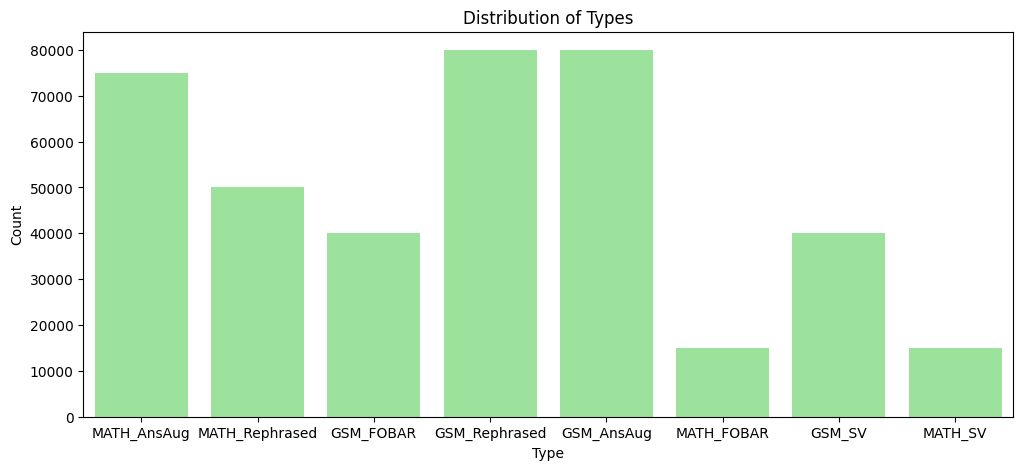

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.countplot(x='type', data=ds, color='lightgreen')
plt.title("Distribution of Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


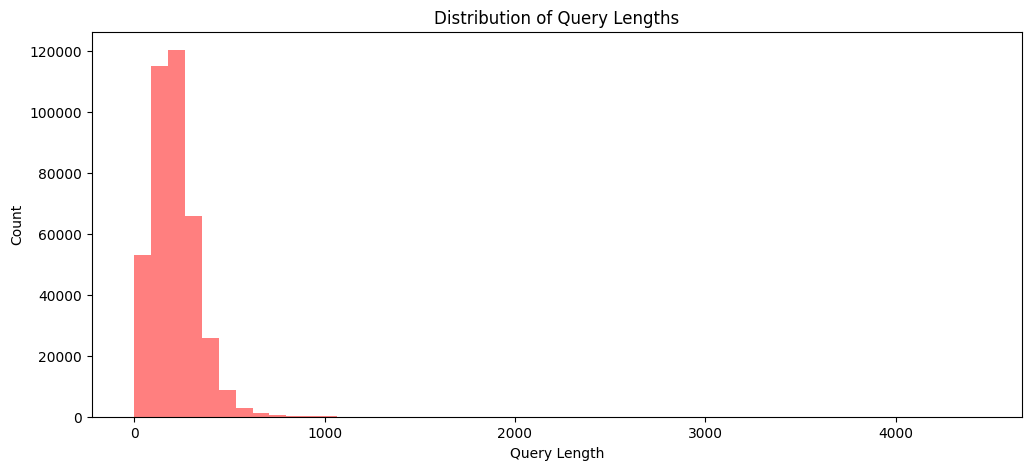

In [9]:
vi_queries = ds['query_vi']
ds['query_len']  = [len(query) for query in vi_queries]

plt.figure(figsize=(12, 5))
plt.hist(ds['query_len'], bins=50, color='red', alpha=0.5)
plt.title("Distribution of Query Lengths")
plt.xlabel("Query Length")
plt.ylabel("Count")
plt.show()

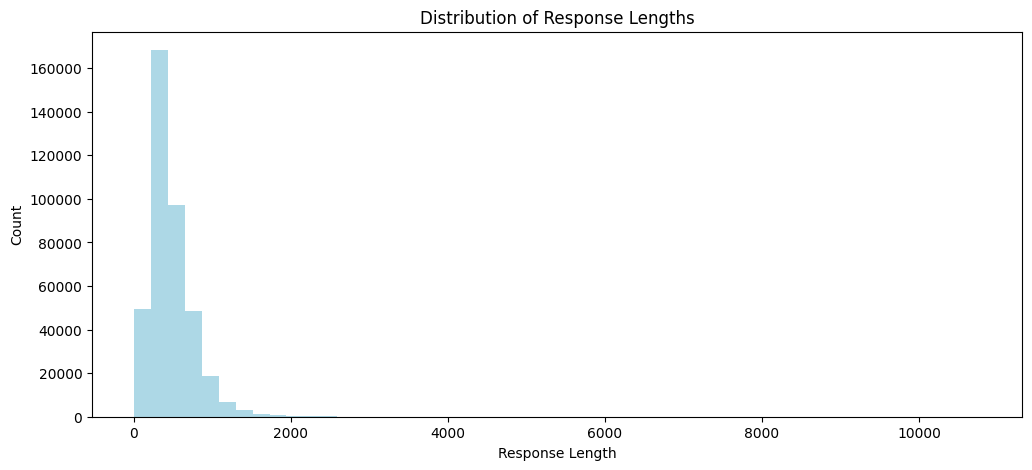

In [10]:
response_queries = ds['response_vi']
ds['response_len'] = [len(response) for response in response_queries]

plt.figure(figsize=(12, 5))
plt.hist(ds['response_len'], bins=50, color='lightblue')
plt.title("Distribution of Response Lengths")
plt.xlabel("Response Length")
plt.ylabel("Count")
plt.show()

In [11]:
ds

,response_en,original_question_en,type,query_en,original_question_vi,query_vi,response_vi,query_len,response_len
0,"The distance between two points $(x_1,y_1)$ an...",Gracie and Joe are choosing numbers on the com...,MATH_AnsAug,Gracie and Joe are choosing numbers on the com...,Gracie và Joe đang chọn số trên mặt phẳng phức...,Gracie và Joe đang chọn số trên mặt phẳng phức...,"Khoảng cách giữa hai điểm $(x_1,y_1)$ và $(x_2...",130,423
1,The area of an equilateral triangle can be fou...,An equilateral triangle has an area of $64\sqr...,MATH_Rephrased,If the area of an equilateral triangle is $64\...,Một tam giác đều có diện tích $64\sqrt{3}$ $\t...,Nếu diện tích của một tam giác đều là $64\sqrt...,Diện tích của một tam giác đều có thể được tín...,140,597
2,Ping pong balls sell for $.10 each.\nJohnny bu...,Ping pong balls sell for $.10 each. Johnny bu...,GSM_FOBAR,Ping pong balls sell for $.10 each. Johnny bu...,"Quả bóng bàn được bán với giá 0,10 USD một quả...","Quả bóng bàn được bán với giá 0,10 USD một quả...","Quả bóng bàn được bán với giá 0,10 USD một quả...",256,569
3,"If $x-5$ is a factor of $P(x)$, then $P(5)=0$....",What must be the value of the coefficient $c$ ...,MATH_Rephrased,What value should the coefficient $c$ have in ...,Giá trị của hệ số $c$ trong $P(x)=x^3+2x^2+cx+...,Hệ số $c$ phải có giá trị bao nhiêu trong đa t...,"Nếu $x-5$ là thừa số của $P(x)$, thì $P(5)=0$....",110,225
4,The total area of the mural is 6m x 3m = 18 sq...,John paints a giant mural that is 6m by 3m. Th...,GSM_Rephrased,What is the total cost of the mural that John ...,John vẽ một bức tranh tường khổng lồ có kích t...,Tổng chi phí cho bức tranh tường mà John đã vẽ...,Tổng diện tích của bức tranh tường là 6m x 3m ...,206,516
...,...,...,...,...,...,...,...,...,...
394995,"If three-fourths of the parrots are green, the...",Three-fourths of the parrots on Bird Island ar...,MATH_Rephrased,If three-fourths of the parrots on Bird Island...,Ba phần tư số vẹt trên Đảo Chim có màu xanh lá...,Nếu 3/4 số vẹt trên Đảo Chim có màu xanh lục v...,Nếu 3/4 số vẹt có màu xanh lá cây thì 1/4 số đ...,116,174
394996,"To solve this problem, we need to determine th...","Aaron, Henry's brother, is 15 years old. Henry...",GSM_SV,"Aaron, Henry's brother, is 15 years old. Henry...","Aaron, anh trai của Henry, 15 tuổi. Chị gái củ...","Aaron, anh trai của Henry, 15 tuổi. Chị gái củ...","Để giải quyết vấn đề này, chúng ta cần xác địn...",191,663
394997,"If Kristen has 12 turtles, Kris has 1/4 * 12 =...",Trey has 7 times as many turtles as Kris. Kris...,GSM_Rephrased,If Kristen has 12 turtles and Kris has 1/4 as ...,Trey có số rùa nhiều gấp 7 lần Kris. Kris có s...,Nếu Kristen có 12 con rùa và Kris có số rùa bằ...,Nếu Kristen có 12 con rùa thì Kris có 1/4 * 12...,142,163
394998,If each fence is 500 meters long and there are...,Emmalyn decided to paint fences in her neighbo...,GSM_AnsAug,Emmalyn decided to paint fences in her neighbo...,Emmalyn quyết định sơn hàng rào trong khu phố ...,Emmalyn quyết định sơn hàng rào trong khu phố ...,Nếu mỗi hàng rào dài 500 mét và có 50 hàng rào...,217,312


### Missing values

In [12]:
res = [i for i, data in ds.iterrows() if len(data['query_vi'])==0 or data['response_vi']==0]

In [13]:
ds.drop(res, inplace=True)

### Drop outliers

In [14]:
def drop_outliers(df, column, lower_quantile=0.01, upper_quantile=0.99):
    q_low = df[column].quantile(lower_quantile)
    q_high = df[column].quantile(upper_quantile)
    df_filtered = df[(df[column] >= q_low) & (df[column] <= q_high)]
    return df_filtered

In [15]:
ds= drop_outliers(ds, 'response_len', lower_quantile=0.05, upper_quantile=0.95)
ds = drop_outliers(ds, 'query_len', lower_quantile=0.05, upper_quantile=0.95)

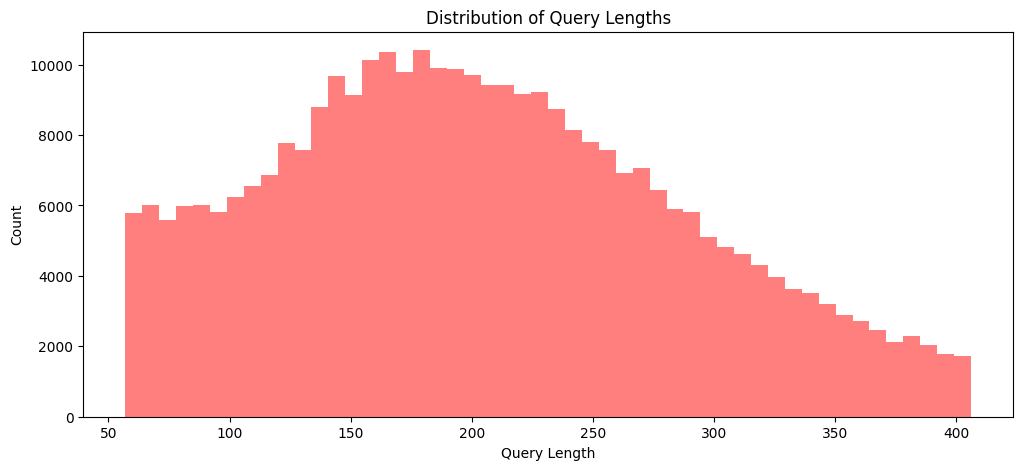

In [16]:
vi_queries = ds['query_vi']
ds['query_len']  = [len(query) for query in vi_queries]

plt.figure(figsize=(12, 5))
plt.hist(ds['query_len'], bins=50, color='red', alpha=0.5)
plt.title("Distribution of Query Lengths")
plt.xlabel("Query Length")
plt.ylabel("Count")
plt.show()

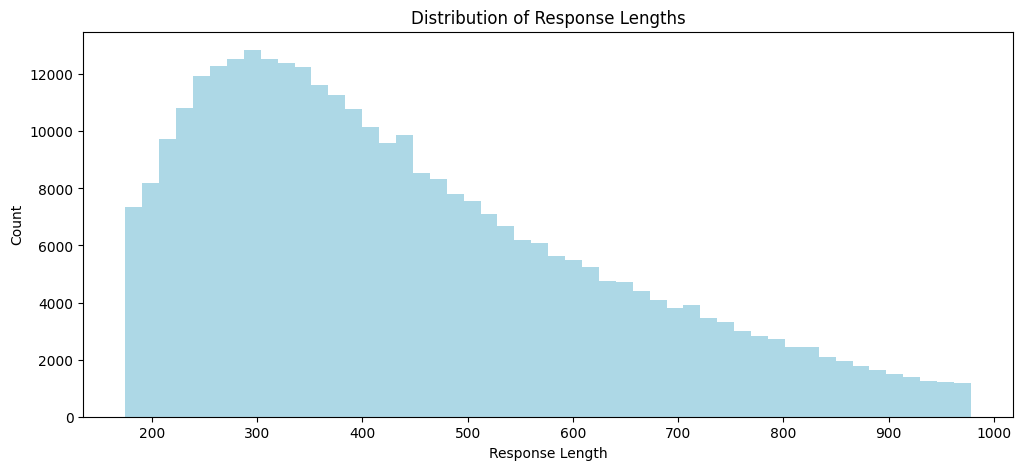

In [17]:
response_queries = ds['response_vi']
ds['response_len'] = [len(response) for response in response_queries]

plt.figure(figsize=(12, 5))
plt.hist(ds['response_len'], bins=50, color='lightblue')
plt.title("Distribution of Response Lengths")
plt.xlabel("Response Length")
plt.ylabel("Count")
plt.show()

### Drop duplicates

In [18]:
ds[['query_vi','response_vi']].duplicated().sum()

np.int64(7393)

In [19]:
ds.drop_duplicates(subset=['query_vi','response_vi'], inplace=True)

## Preprocessing

In [25]:
ds

,response_en,original_question_en,type,query_en,original_question_vi,query_vi,response_vi,query_len,response_len
0,"The distance between two points $(x_1,y_1)$ an...",Gracie and Joe are choosing numbers on the com...,MATH_AnsAug,Gracie and Joe are choosing numbers on the com...,Gracie và Joe đang chọn số trên mặt phẳng phức...,Gracie và Joe đang chọn số trên mặt phẳng phức...,"Khoảng cách giữa hai điểm $(x_1,y_1)$ và $(x_2...",130,423
1,The area of an equilateral triangle can be fou...,An equilateral triangle has an area of $64\sqr...,MATH_Rephrased,If the area of an equilateral triangle is $64\...,Một tam giác đều có diện tích $64\sqrt{3}$ $\t...,Nếu diện tích của một tam giác đều là $64\sqrt...,Diện tích của một tam giác đều có thể được tín...,140,597
2,Ping pong balls sell for $.10 each.\nJohnny bu...,Ping pong balls sell for $.10 each. Johnny bu...,GSM_FOBAR,Ping pong balls sell for $.10 each. Johnny bu...,"Quả bóng bàn được bán với giá 0,10 USD một quả...","Quả bóng bàn được bán với giá 0,10 USD một quả...","Quả bóng bàn được bán với giá 0,10 USD một quả...",256,569
3,"If $x-5$ is a factor of $P(x)$, then $P(5)=0$....",What must be the value of the coefficient $c$ ...,MATH_Rephrased,What value should the coefficient $c$ have in ...,Giá trị của hệ số $c$ trong $P(x)=x^3+2x^2+cx+...,Hệ số $c$ phải có giá trị bao nhiêu trong đa t...,"Nếu $x-5$ là thừa số của $P(x)$, thì $P(5)=0$....",110,225
4,The total area of the mural is 6m x 3m = 18 sq...,John paints a giant mural that is 6m by 3m. Th...,GSM_Rephrased,What is the total cost of the mural that John ...,John vẽ một bức tranh tường khổng lồ có kích t...,Tổng chi phí cho bức tranh tường mà John đã vẽ...,Tổng diện tích của bức tranh tường là 6m x 3m ...,206,516
...,...,...,...,...,...,...,...,...,...
394993,Annie has 6 barrettes.\nShe has twice as many ...,"Annie has 6 barrettes, twice as many scrunchie...",GSM_Rephrased,"If Annie has 6 barrettes, twice as many scrunc...","Annie có 6 chiếc kẹp tóc, số kẹp tóc nhiều gấp...","Nếu Annie có 6 chiếc kẹp tóc, số kẹp tóc nhiều...",Annie có 6 cái kẹp tóc. Cô ấy có số dây buộc t...,238,552
394994,We know that 2 kg of potatoes costs $6.\nTo fi...,Daphney buys 5 kg of potatoes at the supermark...,GSM_FOBAR,Daphney buys x kg of potatoes at the supermark...,Daphney mua 5 kg khoai tây ở siêu thị. Nếu 2 k...,Daphney mua x kg khoai tây ở siêu thị. Nếu 2 k...,Chúng ta biết rằng 2 kg khoai tây có giá 6 USD...,198,497
394996,"To solve this problem, we need to determine th...","Aaron, Henry's brother, is 15 years old. Henry...",GSM_SV,"Aaron, Henry's brother, is 15 years old. Henry...","Aaron, anh trai của Henry, 15 tuổi. Chị gái củ...","Aaron, anh trai của Henry, 15 tuổi. Chị gái củ...","Để giải quyết vấn đề này, chúng ta cần xác địn...",191,663
394998,If each fence is 500 meters long and there are...,Emmalyn decided to paint fences in her neighbo...,GSM_AnsAug,Emmalyn decided to paint fences in her neighbo...,Emmalyn quyết định sơn hàng rào trong khu phố ...,Emmalyn quyết định sơn hàng rào trong khu phố ...,Nếu mỗi hàng rào dài 500 mét và có 50 hàng rào...,217,312


In [24]:
from datasets import load_dataset, concatenate_datasets

# Define subjects
subjects = [
    "algebra",
    "counting_and_probability",
    "geometry",
    "intermediate_algebra",
    "precalculus",
]

# Load and concatenate all train/test splits
train_datasets = []
test_datasets = []

for subj in subjects:
    ds = load_dataset("EleutherAI/hendrycks_math", subj)
    train_datasets.append(ds["train"])
    test_datasets.append(ds["test"])

# Merge all subjects into single train/test datasets
train_ds = concatenate_datasets(train_datasets)
test_ds = concatenate_datasets(test_datasets)


[11:14:40] INFO     [11:14:40] utils.py:164 INFO NumExpr defaulting to 2 threads.                      ]8;id=846133;file:///usr/local/lib/python3.12/dist-packages/numexpr/utils.py\utils.py]8;;\:]8;id=998059;file:///usr/local/lib/python3.12/dist-packages/numexpr/utils.py#164\164]8;;\

           INFO     [11:14:40] config.py:112 INFO TensorFlow version 2.19.0 available.                ]8;id=822697;file:///usr/local/lib/python3.12/dist-packages/datasets/config.py\config.py]8;;\:]8;id=181104;file:///usr/local/lib/python3.12/dist-packages/datasets/config.py#112\112]8;;\

           INFO     [11:14:40] config.py:125 INFO JAX version 0.7.2 available.                        ]8;id=545748;file:///usr/local/lib/python3.12/dist-packages/datasets/config.py\config.py]8;;\:]8;id=905494;file:///usr/local/lib/python3.12/dist-packages/datasets/config.py#125\125]8;;\

/usr/local/lib/python3.12/dist-packages/praisonaiagents/_warning_patch.py:47: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  _original_warn(message, category, stacklevel, source)


README.md: 0.00B [00:00, ?B/s]

...

Generating test split:   0%|          | 0/903 [00:00<?, ? examples/s]

precalculus/train-00000-of-00001.parquet:   0%|          | 0.00/354k [00:00<?, ?B/s]

precalculus/test-00000-of-00001.parquet:   0%|          | 0.00/242k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/746 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/546 [00:00<?, ? examples/s]

In [25]:
train_ds.to_pandas().to_csv("train_data.csv")
test_ds.to_pandas().to_csv("test_data.csv")

## Agent Data Generation

In [26]:
from transformers import AutoModelForCausalLM, AutoTokenizer
model_name = "Qwen/Qwen2.5-Math-1.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Tools

In [ ]:
from typing import Optional, Dict, Any, List
import logging
import math
import statistics
import re
import importlib.util as importlib_util
import wikipedia

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set Wikipedia language to Vietnamese
wikipedia.set_lang("vi")


def WikipediaRetriever(query: str) -> str:
    """
    Retrieve the Vietnamese summary of a Wikipedia page.

    Example:
        >>> WikipediaRetriever("Việt Nam")
    """
    try:
        page = wikipedia.page(query, auto_suggest=True)
        return page.summary

    except wikipedia.exceptions.DisambiguationError as e:
        logger.warning(f"DisambiguationError for '{query}': choosing first option.")
        try:
            page = wikipedia.page(e.options[0])
            return page.summary
        except Exception:
            return f"Nhiều kết quả: {', '.join(e.options[:5])}..."

    except wikipedia.exceptions.PageError:
        return f"Không tìm thấy bài viết cho truy vấn: {query}"

    except Exception as e:
        logger.exception("WikipediaRetriever failed")
        return f"Lỗi khi truy xuất Wikipedia: {str(e)}"


def evaluate(
    expression: str,
    variables: Optional[Dict[str, float]] = None,
    precision: int = 10
) -> Dict[str, Any]:
    """
    Evaluate a mathematical expression safely using SymPy if available,
    otherwise fall back to math-based evaluation.

    Example:
        >>> evaluate("sin(pi/4) + log(e)")
        {'result': 1.7071}
    """
    try:
        variables = variables or {}
        expression = expression.replace("^", "**").strip()

        if importlib_util.find_spec("sympy") is not None:
            import sympy as sp
            local_dict = {
                "sin": sp.sin, "cos": sp.cos, "tan": sp.tan,
                "sqrt": sp.sqrt, "log": sp.log, "exp": sp.exp,
                "pi": sp.pi, "e": sp.E, "ln": sp.log
            }

            for var in variables.keys():
                if var not in local_dict:
                    local_dict[var] = sp.Symbol(var)

            expr = sp.sympify(expression, locals=local_dict)
            if variables:
                expr = expr.subs(variables)

            result = float(sp.N(expr, precision))
            return {"result": round(result, precision)}

        else:
            # Safe fallback using math
            allowed = {k: getattr(math, k) for k in dir(math) if not k.startswith("_")}
            safe_env = {"__builtins__": None, **allowed, **variables}

            forbidden = ["__", "import", "os.", "sys.", "eval", "exec", "open"]
            if any(f in expression for f in forbidden):
                return {"error": "Unsafe expression detected."}

            result = eval(expression, safe_env, {})
            return {"result": round(float(result), precision)}

    except Exception as e:
        logger.exception("Error evaluating expression")
        return {"error": f"Error evaluating expression: {str(e)}"}

def solve_equation(equation: str, variable: str = "x") -> Dict[str, Any]:
    """
    Solve mathematical equations symbolically using SymPy.

    Example:
        >>> solve_equation("2*x + 3 = 7")
        {'solutions': [2.0]}
    """
    try:
        if importlib_util.find_spec("sympy") is None:
            return {"error": "sympy is not installed. Please install it with: pip install sympy"}

        import sympy as sp

        eqn = equation.replace("^", "**")
        var = sp.Symbol(variable, real=True)

        if "=" in eqn:
            left, right = eqn.split("=", 1)
            expr = sp.sympify(left) - sp.sympify(right)
        else:
            expr = sp.sympify(eqn)

        sols = sp.solve(expr, var)
        real_solutions = [float(sp.N(s)) for s in sols if s.is_real]

        if real_solutions:
            return {"solutions": real_solutions}
        return {"error": "No real solutions found"}

    except Exception as e:
        logger.exception("Error solving equation")
        return {"error": f"Error solving equation: {str(e)}"}


def convert_units(value: float, from_unit: str, to_unit: str) -> float:
    """
    Convert between compatible units (length or weight).

    Supported:
      - length: m, cm, mm, km, in, ft, yd, mi
      - weight: g, kg, mg, lb, oz
    """
    length_units = {
        "m": 1.0, "cm": 0.01, "mm": 0.001, "km": 1000.0,
        "in": 0.0254, "ft": 0.3048, "yd": 0.9144, "mi": 1609.34
    }

    weight_units = {
        "kg": 1.0, "g": 0.001, "mg": 1e-6, "lb": 0.453592, "oz": 0.0283495
    }

    systems = [length_units, weight_units]
    for sys in systems:
        if from_unit in sys:
            if to_unit not in sys:
                raise ValueError("Incompatible units (length vs weight)")
            return value * sys[from_unit] / sys[to_unit]

    raise ValueError("Unsupported units")



In [95]:
tools = [
    {
        "type": "function",
        "function": {
            "name": "WikipediaRetriever",
            "description": "Return relevant Wikipedia document text for a query.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {
                        "type": "string",
                        "description": "Search query topic, e.g. 'Việt Nam'",
                    },
                    "k": {
                        "type": "integer",
                        "description": "Number of sentences to return",
                        "default": 5,
                    },
                },
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "evaluate",
            "description": "Evaluate a mathematical expression with optional variables and precision control.",
            "parameters": {
                "type": "object",
                "properties": {
                    "expression": {
                        "type": "string",
                        "description": "Expression to evaluate, e.g. 'sin(pi/4) + 2^3'.",
                    },
                    "variables": {
                        "type": "object",
                        "description": "Optional mapping of variable names to numeric values.",
                    },
                    "precision": {
                        "type": "integer",
                        "description": "Decimal precision for result rounding.",
                        "default": 10,
                    },
                },
                "required": ["expression"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "solve_equation",
            "description": "Solve a mathematical equation for a specified variable (e.g. '2*x + 3 = 7').",
            "parameters": {
                "type": "object",
                "properties": {
                    "equation": {
                        "type": "string",
                        "description": "Equation or expression to solve.",
                    },
                    "variable": {
                        "type": "string",
                        "description": "Variable to solve for (default: 'x').",
                        "default": "x",
                    },
                },
                "required": ["equation"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "convert_units",
            "description": "Convert numeric values between supported units (length or weight).",
            "parameters": {
                "type": "object",
                "properties": {
                    "value": {
                        "type": "number",
                        "description": "Numeric value to convert.",
                    },
                    "from_unit": {
                        "type": "string",
                        "description": "Source unit (e.g. 'km', 'm', 'ft', 'kg').",
                    },
                    "to_unit": {
                        "type": "string",
                        "description": "Target unit (e.g. 'm', 'cm', 'lb', 'g').",
                    },
                },
                "required": ["value", "from_unit", "to_unit"],
            },
        },
    }
]


In [53]:
query = "1+1 là bao nhiêu?"
response = "kết quả là 2"
message = [
        {"role": "system", "content": "Hãy trả lời câu hỏi nhanh."},
        {"role": "user", "content": "1+1 là bao nhiêu?"},
        {
            "role": "assistant",
            "content": "I'll compute the numeric expression first.",
            "tool_calls": [
                {
                    "function": {
                        "name": "evaluate",
                        "arguments": {"expression": "1+1"}
                    }
                }
            ]
        },
        {"role": "tool", "content": "2"},
        {"role": "assistant", "content": "kết quả là 2"}
]

print(tokenizer.apply_chat_template(
            message,
            tokenize=False,
            add_generation_prompt=False,
            tools = tools
        ))

<|im_start|>system
Please give your final answer.

# Tools

You may call one or more functions to assist with the user query.

You are provided with function signatures within <tools></tools> XML tags:
<tools>
{"type": "function", "function": {"name": "WikipediaRetriever", "description": "Return relevant Wikipedia document text for a query.", "parameters": {"type": "object", "properties": {"query": {"type": "string", "description": "Search query topic, e.g. 'Việt Nam'"}, "k": {"type": "integer", "description": "Number of sentences to return", "default": 5}}, "required": ["query"]}}}
{"type": "function", "function": {"name": "evaluate", "description": "Evaluate a mathematical expression with optional variables and precision control.", "parameters": {"type": "object", "properties": {"expression": {"type": "string", "description": "Expression to evaluate, e.g. 'sin(pi/4) + 2^3'."}, "variables": {"type": "object", "description": "Optional mapping of variable names to numeric values."}, "pr

In [94]:
examples = [
    [
    {"role": "system", "content": "Hãy trả lời câu hỏi nhanh."},
    {"role": "user", "content": "Gracie và Joe đang ở cách xa nhau 5m. Vậy họ cách xa nhau bao nhiêu km?"},
    {
        "role": "assistant",
        "content": "I'll convert the distance from meters to kilometers.",
        "tool_calls": [
            {
                "function": {
                    "name": "convert_units",
                    "arguments": {
                        "value": 5,
                        "from_unit": "m",
                        "to_unit": "km"
                    }
                }
            }
        ]
    },
    {"role": "tool", "content": "0.005"},
    {"role": "assistant", "content": "Gracie và Joe cách nhau 0.005 km."}
],
[
    {"role": "system", "content": "Hãy trả lời câu hỏi nhanh."},
    {"role": "user", "content": "Gracie và Joe đang chọn số trên mặt phẳng phức. Joe chọn điểm 1+2i. Gracie chọn -1+i. Điểm của Gracie và Joe cách nhau bao xa?"},
    {
        "role": "assistant",
        "content": "I'll compute the distance between the two complex points.",
        "tool_calls": [
            {
                "function": {
                    "name": "evaluate",
                    "arguments": {
                        "expression": "sqrt(((-1)-(1))^2 + ((1)-(2))^2)"
                    }
                }
            }
        ]
    },
    {"role": "tool", "content": "2.2360679775"},
    {"role": "assistant", "content": "Khoảng cách giữa hai điểm là 2.2360679775 đơn vị."}
],
[
    {"role": "system", "content": "Hãy trả lời câu hỏi nhanh."},
    {
        "role": "user",
        "content": "Một đội diễu hành được sắp xếp theo hình chữ nhật gồm m thành viên trong mỗi hàng và có r hàng, với m và r là các số nguyên. Đội này có ít hơn 100 thành viên. Khi sắp xếp như vậy, người quản lý thấy còn dư 2 người. Nếu ông ấy tăng số thành viên mỗi hàng thêm 1 và giảm số hàng đi 2, thì vừa đủ chỗ cho tất cả. Hỏi đội có thể có nhiều nhất bao nhiêu thành viên?"
    },
    {
        "role": "assistant",
        "content": "Giả sử đội có tổng cộng N thành viên. Khi sắp xếp thành r hàng và mỗi hàng có m người, ta có:\n\nN = m × r + 2.\n\nNếu tăng số người mỗi hàng lên 1 và giảm số hàng đi 2, ta có:\n\nN = (m + 1) × (r - 2).\n\nTừ đó, ta có phương trình:\n\nm × r + 2 = (m + 1)(r - 2).\n\nKhai triển và rút gọn:\n\nmr + 2 = mr - 2m + r - 2 ⟹ 2m - r = 4 ⟹ r = 2m - 4.\n\nThay vào N = m × r + 2:\n\nN = m(2m - 4) + 2 = 2m² - 4m + 2.\n\nVì N < 100, ta có:\n\n2m² - 4m + 2 < 100 ⟹ 2m² - 4m - 98 < 0.\n\nChia hai vế cho 2:\n\nm² - 2m - 49 < 0.\n\nNghiệm của phương trình m² - 2m - 49 = 0 là m = 1 ± √50 ≈ 1 ± 7.07.\n\nSuy ra 0 < m < 8.07 ⟹ m ≤ 8.\n\nThử với m = 8:\n\nr = 2m - 4 = 12,\nN = 2 × 8² - 4 × 8 + 2 = 98.\n\n→ Đội có thể có nhiều nhất **98 thành viên**."
    },
    {
        "role": "assistant",
        "content": "Đáp án: 98."
    }
],
    [
    {"role": "system", "content": "Hãy trả lời câu hỏi nhanh."},
    {
        "role": "user",
        "content": "Bậc của đa thức (4 + 5x^3 + 100 + 2πx^4 + √10x^4 + 9) là bao nhiêu?"
    },
    {
        "role": "assistant",
        "content": "Ta gom các hạng tử cùng bậc trong đa thức.\nĐa thức có các hạng tử: 4, 100, 9 (bậc 0), 5x³ (bậc 3), 2πx⁴ và √10x⁴ (bậc 4).\nHạng tử có bậc cao nhất là x⁴, nên bậc của đa thức là 4."
    },
    {
        "role": "assistant",
        "content": "Đáp án: 4."
    }
]
]

In [81]:
solve_equation("(m * 3) + 2 = 0")

{'solutions': [-0.6666666666666666]}

In [77]:
def solve_equation(equation: str, variable: str = "x") -> Dict[str, Any]:
    """
    Solve mathematical equations symbolically using SymPy.

    Example:
        >>> solve_equation("2*x + 3 = 7")
        {'solutions': [2.0]}
    """
    try:
        if importlib_util.find_spec('sympy') is None:
            error_msg = "sympy package is not available. Please install it using: pip install sympy"
            logging.error(error_msg)
            return {"error": error_msg}

        # Import sympy only when needed
        import sympy

        # Parse equation
        if '=' in equation:
            left, right = equation.split('=')
            equation = f"({left}) - ({right})"

        # Convert to SymPy expression
        x = sympy.Symbol(variable)
        expr = sympy.sympify(equation)

        # Solve equation
        solutions = sympy.solve(expr, x)

        # Convert complex solutions to real if possible
        real_solutions = []
        for sol in solutions:
            if sol.is_real:
                real_solutions.append(float(sol))

        return {"solutions": real_solutions} if real_solutions else {"error": "No real solutions found"}
    except Exception as e:
        error_msg = f"Error solving equation: {str(e)}"
        logging.error(error_msg)
        return {"error": error_msg}

In [83]:
from praisonaiagents import Agent, Task, PraisonAIAgents
from praisonaiagents.tools import (
    evaluate, solve_equation, convert_units,
    calculate_statistics, calculate_financial
)

In [87]:
!pip install langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.2/471.2 kB 26.4 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.79
    Uninstalling langchain-core-0.3.79:
      Successfully uninstalled langchain-core-0.3.79
  Attempting uninstall: google-ai-generativelanguage
    Found existing installation: google-ai-generativelanguage 0.6.15
    Uninstalling google-ai-generativelanguage-0.6.15:
      Successfully uninstalled google-ai-generativelanguage-0.6.15
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.9.0 which is incompatible.
langchain 0.3.2

In [ ]:
# from langchain_google_genai import GoogleGenerativeAI
# from getpass import getpass

# api_key = getpass()
# llm = GoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=api_key, output_structure = dict)

In [117]:
prompt = """
Bạn là một chuyên gia tạo mẫu dữ liệu chuyên nghiệp.

Tôi có một số công cụ (tools) hỗ trợ:
{tools}

Tôi có một số ví dụ về mẫu dữ liệu đã được tạo trước đó:
{examples}

Nhiệm vụ của bạn:
Dựa trên **câu hỏi** và **câu trả lời** bằng tiếng Anh được cung cấp bên dưới, hãy:
1. Tạo **một mẫu dữ liệu mới** theo cùng phong cách, cấu trúc, và định dạng với các ví dụ ở trên.
2. **Dịch toàn bộ dữ liệu này sang tiếng Việt** sao cho tự nhiên, chính xác, và giữ nguyên ý nghĩa ban đầu.
3. Đảm bảo đầu ra phù hợp để sử dụng làm mẫu dữ liệu huấn luyện hoặc kiểm thử.

**Đầu vào:**
- Câu hỏi: {query}
- Câu trả lời: {answer}

**Đầu ra mong muốn:**
- Một mẫu dữ liệu hoàn chỉnh (theo đúng định dạng của các ví dụ), nếu
- Phiên bản tiếng Việt tự nhiên, rõ ràng, và thống nhất về phong cách.
"""

from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate(template=prompt, input_variables=["tools","examples","query", "response"])


In [ ]:
train_df = pd.read_csv("/content/train_data.csv")
test_df = pd.read_csv("/content/test_data.csv")

def generate_data(df, llm):

    res_list = []
    for idx, row in df.iterrows():
        question = row["problem"]
        answer = row["solution"]
        prompt = prompt_template.format(query=question, response=answer)
        res = llm.invoke(prompt)
        res_list.append(res)
    df['generated_data'] = res_list
    return df




In [111]:
sample = train_df.sample(1)
sample

,Unnamed: 0,problem,level,type,solution
1768,1768,Jason is trying to remember the five digit com...,Level 3,Counting & Probability,"Of the digits 1 through 5, three are odd and t..."


In [120]:
question= sample["problem"].values[0]
answer = sample["solution"].values[0]
print(prompt_template.format(query=question, answer=answer, examples= examples, tools=tools))


Bạn là một chuyên gia tạo mẫu dữ liệu chuyên nghiệp.

Tôi có một số công cụ (tools) hỗ trợ:
[{'type': 'function', 'function': {'name': 'WikipediaRetriever', 'description': 'Return relevant Wikipedia document text for a query.', 'parameters': {'type': 'object', 'properties': {'query': {'type': 'string', 'description': "Search query topic, e.g. 'Việt Nam'"}, 'k': {'type': 'integer', 'description': 'Number of sentences to return', 'default': 5}}, 'required': ['query']}}}, {'type': 'function', 'function': {'name': 'evaluate', 'description': 'Evaluate a mathematical expression with optional variables and precision control.', 'parameters': {'type': 'object', 'properties': {'expression': {'type': 'string', 'description': "Expression to evaluate, e.g. 'sin(pi/4) + 2^3'."}, 'variables': {'type': 'object', 'description': 'Optional mapping of variable names to numeric values.'}, 'precision': {'type': 'integer', 'description': 'Decimal precision for result rounding.', 'default': 10}}, 'required':

In [121]:
res = llm.invoke(prompt_template.format(query=question, answer=answer, examples= examples, tools=tools))

'```json\n[\n  {\n    "role": "system",\n    "content": "Hãy trả lời câu hỏi nhanh."\n  },\n  {\n    "role": "user",\n    "content": "Jason đang cố gắng nhớ mật khẩu năm chữ số của két sắt. Anh ấy biết rằng mình chỉ sử dụng các chữ số từ 1 đến 5 (có thể lặp lại), rằng mỗi chữ số chẵn đều được theo sau bởi một chữ số lẻ, và mỗi chữ số lẻ đều được theo sau bởi một chữ số chẵn. Jason cần thử bao nhiêu tổ hợp có thể có?"\n  },\n  {\n    "role": "assistant",\n    "content": "Để tìm tổng số tổ hợp, tôi sẽ tính số tổ hợp bắt đầu bằng chữ số lẻ và số tổ hợp bắt đầu bằng chữ số chẵn, sau đó cộng chúng lại. Đối với các tổ hợp bắt đầu bằng chữ số lẻ, có 3 lựa chọn cho chữ số đầu tiên (1, 3, 5), 2 cho chữ số thứ hai (chẵn), 3 cho chữ số thứ ba (lẻ), 2 cho chữ số thứ tư (chẵn) và 3 cho chữ số thứ năm (lẻ). Đối với các tổ hợp bắt đầu bằng chữ số chẵn, có 2 lựa chọn cho chữ số đầu tiên (2, 4), 3 cho chữ số thứ hai (lẻ), 2 cho chữ số thứ ba (chẵn), 3 cho chữ số thứ tư (lẻ) và 2 cho chữ số thứ năm (chẵ

In [122]:
output = '''
```json
[
  {
    "role": "system",
    "content": "Hãy trả lời câu hỏi nhanh."
  },
  {
    "role": "user",
    "content": "Jason đang cố gắng nhớ mật khẩu năm chữ số của két sắt. Anh ấy biết rằng mình chỉ sử dụng các chữ số từ 1 đến 5 (có thể lặp lại), rằng mỗi chữ số chẵn đều được theo sau bởi một chữ số lẻ, và mỗi chữ số lẻ đều được theo sau bởi một chữ số chẵn. Jason cần thử bao nhiêu tổ hợp có thể có?"
  },
  {
    "role": "assistant",
    "content": "Để tìm tổng số tổ hợp, tôi sẽ tính số tổ hợp bắt đầu bằng chữ số lẻ và số tổ hợp bắt đầu bằng chữ số chẵn, sau đó cộng chúng lại. Đối với các tổ hợp bắt đầu bằng chữ số lẻ, có 3 lựa chọn cho chữ số đầu tiên (1, 3, 5), 2 cho chữ số thứ hai (chẵn), 3 cho chữ số thứ ba (lẻ), 2 cho chữ số thứ tư (chẵn) và 3 cho chữ số thứ năm (lẻ). Đối với các tổ hợp bắt đầu bằng chữ số chẵn, có 2 lựa chọn cho chữ số đầu tiên (2, 4), 3 cho chữ số thứ hai (lẻ), 2 cho chữ số thứ ba (chẵn), 3 cho chữ số thứ tư (lẻ) và 2 cho chữ số thứ năm (chẵn). Tôi sẽ tính tổng của hai trường hợp này."
  },
  {
    "tool_calls": [
      {
        "function": {
          "name": "evaluate",
          "arguments": {
            "expression": "(3*2*3*2*3) + (2*3*2*3*2)"
          }
        }
      }
    ]
  },
  {
    "role": "tool",
    "content": "180"
  },
  {
    "role": "assistant",
    "content": "Jason cần thử 180 tổ hợp có thể có."
  }
]
```
'''.strip()


'```json\n[\n  {\n    "role": "system",\n    "content": "Hãy trả lời câu hỏi nhanh."\n  },\n  {\n    "role": "user",\n    "content": "Jason đang cố gắng nhớ mật khẩu năm chữ số của két sắt. Anh ấy biết rằng mình chỉ sử dụng các chữ số từ 1 đến 5 (có thể lặp lại), rằng mỗi chữ số chẵn đều được theo sau bởi một chữ số lẻ, và mỗi chữ số lẻ đều được theo sau bởi một chữ số chẵn. Jason cần thử bao nhiêu tổ hợp có thể có?"\n  },\n  {\n    "role": "assistant",\n    "content": "Để tìm tổng số tổ hợp, tôi sẽ tính số tổ hợp bắt đầu bằng chữ số lẻ và số tổ hợp bắt đầu bằng chữ số chẵn, sau đó cộng chúng lại. Đối với các tổ hợp bắt đầu bằng chữ số lẻ, có 3 lựa chọn cho chữ số đầu tiên (1, 3, 5), 2 cho chữ số thứ hai (chẵn), 3 cho chữ số thứ ba (lẻ), 2 cho chữ số thứ tư (chẵn) và 3 cho chữ số thứ năm (lẻ). Đối với các tổ hợp bắt đầu bằng chữ số chẵn, có 2 lựa chọn cho chữ số đầu tiên (2, 4), 3 cho chữ số thứ hai (lẻ), 2 cho chữ số thứ ba (chẵn), 3 cho chữ số thứ tư (lẻ) và 2 cho chữ số thứ năm (chẵ

In [124]:
if output.startswith("```json"):
    output = output[7:]
elif output.startswith("```"):
    output = output[3:]
if output.endswith("```"):
    output = output[:-3]
output = output.strip()
output

'[\n  {\n    "role": "system",\n    "content": "Hãy trả lời câu hỏi nhanh."\n  },\n  {\n    "role": "user",\n    "content": "Jason đang cố gắng nhớ mật khẩu năm chữ số của két sắt. Anh ấy biết rằng mình chỉ sử dụng các chữ số từ 1 đến 5 (có thể lặp lại), rằng mỗi chữ số chẵn đều được theo sau bởi một chữ số lẻ, và mỗi chữ số lẻ đều được theo sau bởi một chữ số chẵn. Jason cần thử bao nhiêu tổ hợp có thể có?"\n  },\n  {\n    "role": "assistant",\n    "content": "Để tìm tổng số tổ hợp, tôi sẽ tính số tổ hợp bắt đầu bằng chữ số lẻ và số tổ hợp bắt đầu bằng chữ số chẵn, sau đó cộng chúng lại. Đối với các tổ hợp bắt đầu bằng chữ số lẻ, có 3 lựa chọn cho chữ số đầu tiên (1, 3, 5), 2 cho chữ số thứ hai (chẵn), 3 cho chữ số thứ ba (lẻ), 2 cho chữ số thứ tư (chẵn) và 3 cho chữ số thứ năm (lẻ). Đối với các tổ hợp bắt đầu bằng chữ số chẵn, có 2 lựa chọn cho chữ số đầu tiên (2, 4), 3 cho chữ số thứ hai (lẻ), 2 cho chữ số thứ ba (chẵn), 3 cho chữ số thứ tư (lẻ) và 2 cho chữ số thứ năm (chẵn). Tôi s

In [125]:
json.loads(output)

[{'role': 'system', 'content': 'Hãy trả lời câu hỏi nhanh.'},
 {'role': 'user',
  'content': 'Jason đang cố gắng nhớ mật khẩu năm chữ số của két sắt. Anh ấy biết rằng mình chỉ sử dụng các chữ số từ 1 đến 5 (có thể lặp lại), rằng mỗi chữ số chẵn đều được theo sau bởi một chữ số lẻ, và mỗi chữ số lẻ đều được theo sau bởi một chữ số chẵn. Jason cần thử bao nhiêu tổ hợp có thể có?'},
 {'role': 'assistant',
  'content': 'Để tìm tổng số tổ hợp, tôi sẽ tính số tổ hợp bắt đầu bằng chữ số lẻ và số tổ hợp bắt đầu bằng chữ số chẵn, sau đó cộng chúng lại. Đối với các tổ hợp bắt đầu bằng chữ số lẻ, có 3 lựa chọn cho chữ số đầu tiên (1, 3, 5), 2 cho chữ số thứ hai (chẵn), 3 cho chữ số thứ ba (lẻ), 2 cho chữ số thứ tư (chẵn) và 3 cho chữ số thứ năm (lẻ). Đối với các tổ hợp bắt đầu bằng chữ số chẵn, có 2 lựa chọn cho chữ số đầu tiên (2, 4), 3 cho chữ số thứ hai (lẻ), 2 cho chữ số thứ ba (chẵn), 3 cho chữ số thứ tư (lẻ) và 2 cho chữ số thứ năm (chẵn). Tôi sẽ tính tổng của hai trường hợp này.'},
 {'tool

In [137]:
import json

def generate_data(df, llm):
    res_list = []

    for i, row in df.iterrows():
        question = row["problem"]
        answer = row["solution"]

        # ✅ match variable names with prompt_template
        prompt = prompt_template.format(
            query=question,
            answer=answer,   # use 'response' instead of 'answer'
            examples=examples,
            tools=tools
        )

        try:
            output = llm.invoke(prompt)

            # ✅ make sure output is a string
            if not isinstance(output, str):
                output = str(output)

            # ✅ remove markdown code fences safely
            output = output.strip()
            if output.startswith("```json"):
                output = output[len("```json"):].strip()
            elif output.startswith("```"):
                output = output[len("```"):].strip()
            if output.endswith("```"):
                output = output[:-3].strip()

            try:
                parsed = json.loads(output)
            except json.JSONDecodeError:
                print(f"⚠️ Warning: Row {i} output not valid JSON, saving raw text instead.")
                parsed = output

            res_list.append(parsed)
            print(f"✅ Row {i} processed successfully")

        except Exception as e:
            print(f"❌ Error at row {i}: {e}")
            res_list.append(None)

    df["generated_data"] = res_list
    return df


In [138]:
generate_data(train_df,llm)

⚠️ Warning: Row 0 output not valid JSON, saving raw text instead.
✅ Row 0 processed successfully


KeyboardInterrupt: 